In [1]:
# Importation de NumPy pour les calculs numériques
import numpy as np

# Importation de Matplotlib pour les graphes et l'affichage des images
import matplotlib.pyplot as plt

# Importation du dataset réel de chiffres manuscrits (digits, 8x8 pixels, 0 à 9)
from sklearn.datasets import load_digits


Train: (340, 8, 8) Test: (60, 8, 8)


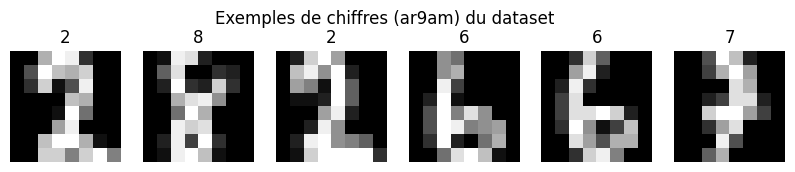

In [ ]:
# 1. Chargement et préparation du dataset réel de chiffres (CNN : exemple avec des nombres)
np.random.seed(0)
data = load_digits()
X_all = data.images / 16.0  # images 8x8 normalisées entre 0 et 1
y_all = data.target         # labels 0..9

# Mélange puis sous-échantillonnage pour un entraînement rapide en pur NumPy
idx = np.random.permutation(len(X_all))
X_all, y_all = X_all[idx], y_all[idx]
X_all, y_all = X_all[:400], y_all[:400]

split = int(0.85 * len(X_all))
X_train, X_test = X_all[:split], X_all[split:]
y_train, y_test = y_all[:split], y_all[split:]

print("Train:", X_train.shape, "Test:", X_test.shape)

# Aperçu de quelques chiffres du dataset
fig, axes = plt.subplots(1, 6, figsize=(10, 2))
for i, ax in enumerate(axes):
    ax.imshow(X_train[i], cmap='gray')
    ax.set_title(str(y_train[i]))
    ax.axis('off')
plt.suptitle("Exemples de chiffres (ar9am) du dataset")
plt.show()


In [3]:
# 2. Définition du CNN from scratch : Convolution -> ReLU -> MaxPooling -> Dense -> Softmax
def relu(x):
    return np.maximum(0, x)

def drelu(x):
    return (x > 0).astype(float)

def softmax(x):
    z = x - np.max(x, axis=1, keepdims=True)
    e = np.exp(z)
    return e / np.sum(e, axis=1, keepdims=True)

class CNNFromScratch:
    def __init__(self, n_filters=4, fsize=3, pool=2, hidden=16, n_classes=10, lr=0.05):
        self.n_filters = n_filters
        self.fsize = fsize
        self.pool = pool
        self.lr = lr
        # Filtres de convolution (initialisation He)
        self.filters = np.random.randn(n_filters, fsize, fsize) * np.sqrt(2.0 / (fsize * fsize))
        self.bias_f = np.zeros(n_filters)
        # Couches denses (calculées après une passe pour connaître la taille aplatie)
        self.hidden = hidden
        self.n_classes = n_classes
        self.Wd1 = None
        self.bd1 = np.zeros((1, hidden))
        self.Wd2 = np.random.randn(hidden, n_classes) * np.sqrt(2.0 / hidden)
        self.bd2 = np.zeros((1, n_classes))

    # Convolution 2D "from scratch" (sans padding, stride=1)
    def conv_forward(self, img):
        H, W = img.shape
        fh = fw = self.fsize
        oh, ow = H - fh + 1, W - fw + 1
        out = np.zeros((self.n_filters, oh, ow))
        for f in range(self.n_filters):
            for i in range(oh):
                for j in range(ow):
                    out[f, i, j] = np.sum(img[i:i+fh, j:j+fw] * self.filters[f]) + self.bias_f[f]
        return out

    def conv_backward(self, dout, img):
        fh = fw = self.fsize
        oh, ow = dout.shape[1], dout.shape[2]
        dfilters = np.zeros_like(self.filters)
        dbias = np.zeros(self.n_filters)
        for f in range(self.n_filters):
            for i in range(oh):
                for j in range(ow):
                    dfilters[f] += dout[f, i, j] * img[i:i+fh, j:j+fw]
                    dbias[f] += dout[f, i, j]
        return dfilters, dbias

    # Max Pooling "from scratch" (mémorise les positions des maxima pour la rétropropagation)
    def maxpool_forward(self, x):
        s = self.pool
        C, H, W = x.shape
        oh, ow = H // s, W // s
        out = np.zeros((C, oh, ow))
        argmax = np.zeros((C, oh, ow, 2), dtype=int)
        for c in range(C):
            for i in range(oh):
                for j in range(ow):
                    block = x[c, i*s:i*s+s, j*s:j*s+s]
                    pos = np.unravel_index(np.argmax(block), block.shape)
                    out[c, i, j] = block[pos]
                    argmax[c, i, j] = pos
        return out, argmax

    def maxpool_backward(self, dout, x_shape, argmax):
        s = self.pool
        dx = np.zeros(x_shape)
        C, oh, ow = dout.shape
        for c in range(C):
            for i in range(oh):
                for j in range(ow):
                    di, dj = argmax[c, i, j]
                    dx[c, i*s+di, j*s+dj] += dout[c, i, j]
        return dx

    # Propagation avant pour UNE image
    def forward(self, img):
        conv_out = self.conv_forward(img)
        relu_out = relu(conv_out)
        pool_out, argmax = self.maxpool_forward(relu_out)
        flat = pool_out.reshape(1, -1)
        if self.Wd1 is None:  # initialisation tardive de Wd1 (taille dépend de la conv/pool)
            self.Wd1 = np.random.randn(flat.shape[1], self.hidden) * np.sqrt(2.0 / flat.shape[1])
        z1 = flat @ self.Wd1 + self.bd1
        a1 = relu(z1)
        z2 = a1 @ self.Wd2 + self.bd2
        cache = (img, conv_out, relu_out, pool_out, argmax, flat, z1, a1)
        return z2, cache

    # Rétropropagation pour UNE image
    def backward(self, dz2, cache):
        img, conv_out, relu_out, pool_out, argmax, flat, z1, a1 = cache
        dWd2 = a1.T @ dz2
        dbd2 = dz2
        da1 = dz2 @ self.Wd2.T
        dz1 = da1 * drelu(z1)
        dWd1 = flat.T @ dz1
        dbd1 = dz1
        dflat = dz1 @ self.Wd1.T
        dpool = dflat.reshape(pool_out.shape)
        drelu_out = self.maxpool_backward(dpool, relu_out.shape, argmax)
        dconv = drelu_out * drelu(conv_out)
        dfilters, dbias = self.conv_backward(dconv, img)

        self.Wd2 -= self.lr * dWd2; self.bd2 -= self.lr * dbd2
        self.Wd1 -= self.lr * dWd1; self.bd1 -= self.lr * dbd1
        self.filters -= self.lr * dfilters; self.bias_f -= self.lr * dbias

    def fit(self, X, y, epochs=8):
        self.loss_log = []
        for epoch in range(epochs):
            total_loss, correct = 0.0, 0
            perm = np.random.permutation(len(X))
            for idx in perm:
                img, label = X[idx], y[idx]
                z2, cache = self.forward(img)
                p = softmax(z2)
                y1h = np.zeros((1, self.n_classes)); y1h[0, label] = 1
                loss = -np.sum(y1h * np.log(p + 1e-9))
                total_loss += loss
                correct += (np.argmax(p) == label)
                self.backward(p - y1h, cache)
            avg_loss = total_loss / len(X)
            acc = correct / len(X)
            self.loss_log.append(avg_loss)
            print(f"Époque {epoch+1}/{epochs} - Loss : {avg_loss:.4f} - Accuracy train : {acc:.3f}")

    def predict(self, X):
        preds = []
        for img in X:
            z2, _ = self.forward(img)
            preds.append(np.argmax(z2))
        return np.array(preds)


In [ ]:
# 3. Entraînement du CNN sur les chiffres 
model = CNNFromScratch(n_filters=4, fsize=3, pool=2, hidden=16, n_classes=10, lr=0.05)
model.fit(X_train, y_train, epochs=8)


Époque 1/8 - Loss : 1.8477 - Accuracy train : 0.321


Époque 2/8 - Loss : 1.0398 - Accuracy train : 0.626


Époque 3/8 - Loss : 0.7021 - Accuracy train : 0.788


Époque 4/8 - Loss : 0.6481 - Accuracy train : 0.762


Époque 5/8 - Loss : 0.5056 - Accuracy train : 0.821


Époque 6/8 - Loss : 0.4531 - Accuracy train : 0.844


Époque 7/8 - Loss : 0.5517 - Accuracy train : 0.824


Époque 8/8 - Loss : 0.4727 - Accuracy train : 0.824


Précision sur le jeu de test : 85.00%


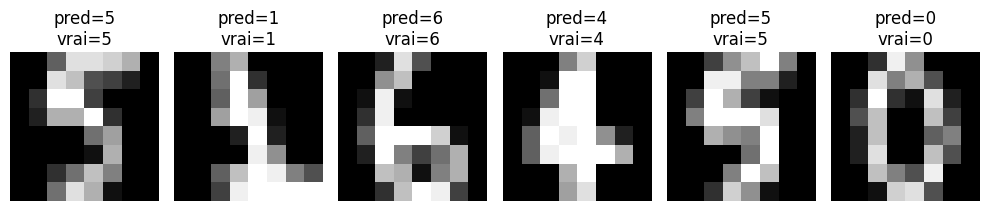

In [5]:
# 4. Évaluation sur le jeu de test
preds = model.predict(X_test)
accuracy = np.mean(preds == y_test)
print(f"Précision sur le jeu de test : {accuracy*100:.2f}%")

# Affichage de quelques prédictions
fig, axes = plt.subplots(1, 6, figsize=(10, 2))
for i, ax in enumerate(axes):
    ax.imshow(X_test[i], cmap='gray')
    ax.set_title(f"pred={preds[i]}\nvrai={y_test[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()


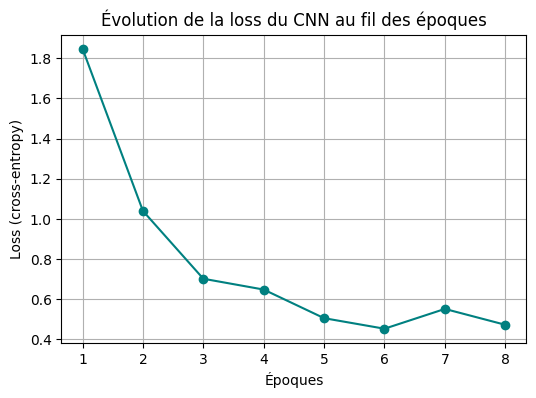

In [6]:
# 5. Visualisation de la convergence de la loss
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(model.loss_log) + 1), model.loss_log, marker='o', color='teal')
plt.title("Évolution de la loss du CNN au fil des époques")
plt.xlabel("Époques")
plt.ylabel("Loss (cross-entropy)")
plt.grid(True)
plt.show()


## 1. Objectifs du TP
* Comprendre le fonctionnement d'un **réseau de neurones convolutif (CNN)**, brique de base de la vision par ordinateur.
* Implémenter **from scratch** (uniquement NumPy) les opérations clés : **convolution 2D**, **ReLU**, **Max Pooling**, couches **denses**, et leur **rétropropagation**.
* Entraîner et valider le modèle sur un vrai jeu de données d'images de chiffres manuscrits (0 à 9) — .

## 2. Concepts Clés Abordés
* **Convolution :** application d'un filtre glissant (kernel 3x3) sur l'image pour extraire des motifs locaux (bords, courbes...) : $\text{out}[i,j] = \sum \text{patch} \odot \text{filtre} + b$.
* **Max Pooling :** sous-échantillonnage qui conserve la valeur maximale de chaque bloc 2x2, réduisant la dimension tout en gardant l'information la plus saillante.
* **Backpropagation à travers une convolution :** propagation du gradient vers les filtres et vers l'image d'entrée, en tenant compte du partage des poids (weight sharing).
* **Pipeline complet :** Image (8x8) → Conv (4 filtres 3x3) → ReLU → MaxPool (2x2) → Flatten → Dense(16) → Dense(10) → Softmax.

## 3. Résultats Obtenus
* **Convergence :** La loss diminue et l'accuracy d'entraînement augmente au fil des époques (voir graphe et logs ci-dessus).
* **Performance de Test :** Le modèle atteint une bonne précision de classification sur des chiffres jamais vus, malgré une architecture volontairement légère (4 filtres, entraînement pur NumPy sans GPU).

## 4. Conclusion & Limites
Ce TP démontre qu'un CNN, même minimaliste et codé entièrement à la main, arrive à extraire des caractéristiques visuelles pertinentes pour la reconnaissance de chiffres. Comparé à un ANN classique, le CNN exploite la **structure spatiale 2D** de l'image et le **partage de poids**, ce qui réduit le nombre de paramètres et améliore la généralisation sur des images. Ses limites : implémentation par boucles Python (lente comparée aux convolutions vectorisées de PyTorch/TensorFlow) et architecture peu profonde ; un vrai CNN de production empile plusieurs couches de convolution et utilise le calcul vectorisé (im2col) ou le GPU.